In [2]:
import os 
import sqlalchemy as sa 
import pandas as pd 
from sqlalchemy import create_engine, text
import sqlite3
import matplotlib.pyplot as plt
import warnings

import yaml

In [5]:
def get_conn_url_from_path(file_path):
    """Returns a connection URL for filedatabases 
    based on the database file path. (To be used within a SQLAlchemy Engine.)
    ---
    Included databases: MSAccess (*.mdb, *.accdb) + SQLite
    """
    ext = os.path.splitext(file_path)[1]

    if ext in ['.mdb', '.accdb']:
        connection_string = (
            rf"DRIVER={{Microsoft Access Driver (*.mdb, *.accdb)}};"
            rf"DBQ={file_path};"
            rf"ExtendedAnsiSQL=1;" # to support DECIMAL(m, n) columns in Access
        )

        # Create URL without usr and pwd 
        connection_url = sa.engine.URL.create(
        "access+pyodbc",
        query={"odbc_connect": connection_string}
        )
    elif ext == '.sqlite':
        connection_url = rf"sqlite:///{path}"

    return connection_url


def get_ADepth_HTypes_from_profile(df_profile):
    """Returns the depth of the A horizons and
    """
    df = df_profile[['HORIZONT', 'TIEFE_OG', 'TIEFE_UG']]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df['HORIZONT'] = df['HORIZONT'].apply(lambda x: x[0])
        df['DEPTH'] = df['TIEFE_UG'] - df['TIEFE_OG']
        df.drop(['TIEFE_OG', 'TIEFE_UG'], axis=1, inplace=True)
    
    num_htypes = df['HORIZONT'].value_counts().shape[0]
    As = df[df['HORIZONT'] == 'A']
    ADepth=0 
    for depth in As[As['HORIZONT'] == 'A']['DEPTH']:
        ADepth += depth

    return ADepth, num_htypes

def calculate_custom_features_from_groups(df, group_by_column, process_function, column_names):
    """
    Groups the DataFrame by the specified column and applies a processing function to each group.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    group_by_column (str): The column name to group by.
    process_function (function): The function to apply to each group.

    Returns:
    pd.DataFrame: A DataFrame with the processed results.
    """
    # Group the DataFrame by the specified column
    grouped = df.groupby(group_by_column)

    # Initialize a list to store the results
    results = []

    # Iterate over each group
    for group_df in grouped:
        # Apply the processing function to the group
        output = process_function(group_df[-1])
        results.append(output)
    
    return pd.DataFrame(results, columns=column_names)


def query_to_df(engine, config, key_to_query): 
    with open(config) as file:
        config_queries = yaml.full_load(file)
    query = config_queries[key_to_query]
    formatted_query = query.replace('\n', ' ').replace('  ', ' ')
    df = pd.read_sql(formatted_query, engine)

    return df

def instanciate_engine(dataset_config_key):
    path = os.path.join(config['data_dir'], config['datasets'][dataset_config_key])
    return sa.create_engine(get_conn_url_from_path(path))

In [7]:
with open('../configs/dataset_creation.yaml') as file:
    config = yaml.full_load(file)

In [7]:
path = os.path.join(config['data_dir'], config['datasets']['bwi_2002'])
engine_bwi_2002 = sa.create_engine(get_conn_url_from_path(path))

In [81]:
insp = sa.inspect(engine_bwi_2002)

In [82]:
insp.get_table_names()

['b0_ecke',
 'b0_tab',
 'b2_ba_natwg',
 'b2_ba_natwg_2012',
 'b2_baeume',
 'b2_Baeume_korr',
 'b2_baeume_var',
 'b2_bestand',
 'b2_bestock',
 'b2_bestock_2012',
 'b2_bestock_baanteile',
 'b2_bestock_gt4m',
 'b2_bestock_gt4m_2012',
 'b2_bestock_gt4m_ba',
 'b2_bestock_le4m',
 'b2_bestock_le4m_2012',
 'b2_bestock_le4m_ba',
 'b2_boden',
 'b2_boden_quer',
 'b2_def_banwg',
 'b2_ecke_raum',
 'b2_ecke_w',
 'b2_idbestand',
 'b2_jung',
 'b2_tab',
 'b2_tab_w',
 'b2_tot_ge20cm',
 'b2_weg',
 'b2_weg_eg',
 'b2_wfkt_ls',
 'b2_wfkt_quer_ls',
 'b2_wrand',
 'b2_wrand_ab',
 'b2_wzp']

In [8]:
with open('../configs/dataset_creation.yaml') as file:
    config = yaml.full_load(file)

In [9]:
query = config['queries']['bwi_2002_ecke']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_ecke = pd.read_sql(formatted_query, engine_bwi_2002)

In [10]:
query = config['queries']['bwi_2002_tab']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_tab = pd.read_sql(formatted_query, engine_bwi_2002)

In [11]:
query = config['queries']['bwi_2002_baeume']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_baeume = pd.read_sql(formatted_query, engine_bwi_2002)

In [12]:
query = config['queries']['bwi_2002_bestand']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_bestand = pd.read_sql(formatted_query, engine_bwi_2002)

In [13]:
df_ecke_info = pd.merge(df_ecke,  df_tab, on=['Tnr'], how='inner')

In [14]:
df_main = pd.merge(df_baeume, df_ecke_info, on=['Tnr', 'Enr'], how='inner')

In [15]:
df_main = pd.merge(df_main, df_bestand, on=['Tnr', 'Enr'], how='inner')

In [16]:
df_main

,Tnr,Enr,Bnr,Av,Ba,Al_ba,Bs,Bhd,Hoehe,D7,...,hnnSt100,hnnSt250,Zaun,Be,NatNaeheHaupt,NatNaeheLT7cm,ForestType,RAN,Situation,TOT
0,11,2,1,0,10,119.0,1,330,132.0,242.0,...,14,255,0,1,2,-1,203,0,0,0
1,11,2,2,0,10,139.0,1,540,176.0,365.0,...,14,255,0,1,2,-1,203,0,0,0
2,11,2,3,0,10,149.0,1,520,261.0,398.0,...,14,255,0,1,2,-1,203,0,0,0
3,11,2,4,0,10,149.0,1,528,217.0,385.0,...,14,255,0,1,2,-1,203,0,0,0
4,14,2,2,0,10,155.0,1,865,378.0,694.0,...,15,255,0,1,2,-1,302,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446577,63814,2,9,0,20,44.0,1,360,147.0,240.0,...,7,253,0,1,3,3,202,1,0,0
446578,63814,2,3001,175,230,NaN,4,1,NaN,NaN,...,7,253,0,1,3,3,202,1,0,0
446579,63814,2,3002,175,230,NaN,4,25,NaN,NaN,...,7,253,0,1,3,3,202,1,0,0
446580,63814,2,3003,175,230,NaN,4,25,NaN,NaN,...,7,253,0,1,3,3,202,1,0,0


In [22]:
df_main.columns

Index(['Tnr', 'Enr', 'Bnr', 'Av', 'Ba', 'Al_ba', 'Bs', 'Bhd', 'Hoehe', 'D7',
       'D03', 'G', 'VolR', 'VolR_FAO', 'VolE', 'vVolE', 'N_ha', 'Stf', 'StfM',
       'Bhdst1', 'Bhdst5', 'Alkl5', 'GrGr2', 'jSchael', 'Biom_o', 'Biom_u',
       'Biov_o', 'Gexp', 'GExpKl4', 'GExpKl8', 'Gform', 'Gneig', 'GneigKl5',
       'natHoe', 'potNatWg', 'HoeheNN', 'hnnSt100', 'hnnSt250', 'Zaun', 'Be',
       'NatNaeheHaupt', 'NatNaeheLT7cm', 'ForestType', 'RAN', 'Situation',
       'TOT'],
      dtype='object')

(array([1318.,  497., 1126., 1035.,  519.,  286.,  128.,   58.,   26.,
           7.]),
 array([-1.0000e+00,  1.4510e+02,  2.9120e+02,  4.3730e+02,  5.8340e+02,
         7.2950e+02,  8.7560e+02,  1.0217e+03,  1.1678e+03,  1.3139e+03,
         1.4600e+03]),
 <BarContainer object of 10 artists>)

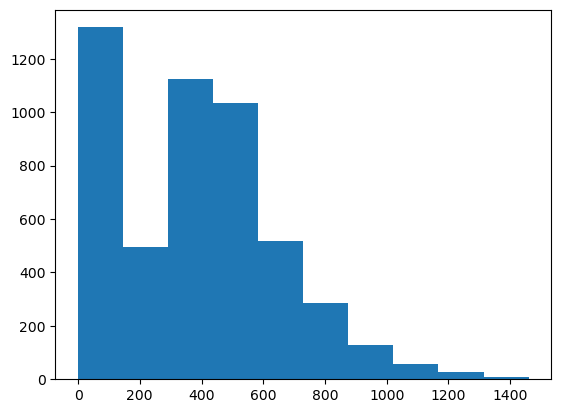

In [35]:
sample = df_main['HoeheNN'].sample(n=5000, random_state=1)
plt.hist(sample)

In [182]:
columns = insp.get_columns('b2_jung')

for column in columns:
    print(f"  {column['name']} ({column['type']})")

  Tnr (INTEGER)
  Enr (SMALLINT)
  Bnr (SMALLINT)
  Bs (SMALLINT)
  Ba (SMALLINT)
  Gr (SMALLINT)
  Verbiss (SMALLINT)
  Schael (SMALLINT)
  Sonst (SMALLINT)
  Schu (SMALLINT)
  Anz (SMALLINT)


In [ ]:
query = config['queries']['bwi_2002_bestand']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_bestand = pd.read_sql(formatted_query, engine_bwi_2002)

Column: Tnr, Type: INTEGER
Column: Enr, Type: SMALLINT
Column: VBl, Type: SMALLINT
Column: InvE1, Type: SMALLINT
Column: InvE2, Type: SMALLINT
Column: InvE2x, Type: SMALLINT
Column: InvE2y, Type: SMALLINT
Column: InvE2z, Type: SMALLINT
Column: InvE3, Type: SMALLINT
Column: InvE3w, Type: SMALLINT
Column: Use12, Type: SMALLINT
Column: Use12z, Type: SMALLINT
Column: Use22y, Type: SMALLINT
Column: Use22z, Type: SMALLINT
Column: Use13, Type: SMALLINT
Column: Use23, Type: SMALLINT
Column: Use23w, Type: SMALLINT
Column: Use2y3, Type: SMALLINT
Column: Use2z3, Type: SMALLINT
Column: Use123, Type: SMALLINT
Column: Use22z3, Type: SMALLINT
Column: Bl, Type: SMALLINT
Column: Gform, Type: SMALLINT
Column: Gneig, Type: SMALLINT
Column: Gexp, Type: SMALLINT
Column: natHoe, Type: SMALLINT
Column: GneigKl5, Type: SMALLINT
Column: GExpKl4, Type: SMALLINT
Column: GExpKl8, Type: SMALLINT
Column: potNatWg, Type: SMALLINT


In [36]:
path = os.path.join(config['data_dir'], config['datasets']['climate'])
engine_climate = sa.create_engine(get_conn_url_from_path(path))

In [38]:
insp_climate = sa.inspect(engine_climate)

In [39]:
table_names = insp_climate.get_table_names()

In [40]:
table_names

[]

In [37]:
engine_climate.table_names()

AttributeError: 'Engine' object has no attribute 'table_names'

In [43]:
df_baeume.columns

Index(['Tnr', 'Enr', 'Bnr', 'Av', 'Ba', 'Al_ba', 'Bs', 'Bhd', 'Hoehe', 'D7',
       'D03', 'G', 'VolR', 'VolR_FAO', 'VolE', 'vVolE', 'N_ha', 'Stf', 'StfM',
       'Bhdst1', 'Bhdst5', 'Alkl5', 'GrGr2', 'jSchael', 'Biom_o', 'Biom_u',
       'Biov_o'],
      dtype='object')

In [44]:
filtered_trees = df_baeume[df_baeume.applymap(lambda x: x == -1).any(axis=1)]


C:\Users\davha\AppData\Local\Temp\ipykernel_112268\3306840189.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  filtered_trees = df_baeume[df_baeume.applymap(lambda x: x == -1).any(axis=1)]


In [45]:
filtered_trees

,Tnr,Enr,Bnr,Av,Ba,Al_ba,Bs,Bhd,Hoehe,D7,...,Stf,StfM,Bhdst1,Bhdst5,Alkl5,GrGr2,jSchael,Biom_o,Biom_u,Biov_o
22,14,4,1001,100,212,NaN,1,1,NaN,NaN,...,2.500342,1.721552,-1,0,4,100,-1.0,0.002294,0.026014,0.001000
23,14,4,3001,175,100,NaN,1,1,NaN,NaN,...,1.330236,0.915903,-1,0,4,101,0.0,0.037763,0.091284,0.001001
24,14,4,3002,175,100,NaN,1,1,NaN,NaN,...,1.330236,0.915903,-1,0,4,101,0.0,0.037763,0.091284,0.001001
25,14,4,3003,175,100,NaN,1,65,NaN,NaN,...,2.325492,1.601164,-1,0,4,102,0.0,12.374224,1.409250,0.025926
42,15,2,1001,100,140,NaN,4,1,NaN,NaN,...,0.000000,0.000000,-1,0,4,100,-1.0,0.002294,0.018256,0.001001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444267,63814,1,3001,175,10,NaN,1,25,NaN,NaN,...,2.945720,9.621127,-1,0,4,102,0.0,1.407389,0.048059,0.002982
444277,63814,2,3001,175,230,NaN,4,1,NaN,NaN,...,0.000000,0.000000,-1,0,4,101,0.0,0.037763,0.130227,0.001001
444278,63814,2,3002,175,230,NaN,4,25,NaN,NaN,...,0.000000,0.000000,-1,0,4,102,0.0,1.402507,0.218877,0.002753
444279,63814,2,3003,175,230,NaN,4,25,NaN,NaN,...,0.000000,0.000000,-1,0,4,102,0.0,1.402507,0.218877,0.002753


In [46]:
filtered_trees = filtered_trees[filtered_trees['Bhd'] != 1]

In [47]:
filtered_trees

,Tnr,Enr,Bnr,Av,Ba,Al_ba,Bs,Bhd,Hoehe,D7,...,Stf,StfM,Bhdst1,Bhdst5,Alkl5,GrGr2,jSchael,Biom_o,Biom_u,Biov_o
25,14,4,3003,175,100,NaN,1,65,NaN,NaN,...,2.325492,1.601164,-1,0,4,102,0.0,12.374224,1.409250,0.025926
160,23,3,3001,175,30,NaN,1,25,NaN,NaN,...,2.948175,0.942238,-1,0,4,102,0.0,1.407389,0.048059,0.002982
161,23,3,3002,175,10,NaN,1,55,NaN,NaN,...,3.313287,1.058928,-1,0,4,102,0.0,6.477564,0.434490,0.015228
162,23,3,3003,175,10,NaN,1,65,NaN,NaN,...,3.497070,1.117665,-1,0,4,102,0.0,9.463040,0.692748,0.022603
169,23,4,3001,175,212,NaN,1,25,NaN,NaN,...,2.713530,1.000703,-1,0,4,102,0.0,1.402507,0.218877,0.002296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444164,63801,4,3001,175,140,NaN,4,30,NaN,NaN,...,0.000000,0.000000,-1,0,4,102,0.0,3.229236,0.334757,0.004607
444165,63801,4,3002,175,130,NaN,4,30,NaN,NaN,...,0.000000,0.000000,-1,0,4,102,0.0,3.229236,0.334757,0.004607
444267,63814,1,3001,175,10,NaN,1,25,NaN,NaN,...,2.945720,9.621127,-1,0,4,102,0.0,1.407389,0.048059,0.002982
444278,63814,2,3002,175,230,NaN,4,25,NaN,NaN,...,0.000000,0.000000,-1,0,4,102,0.0,1.402507,0.218877,0.002753


In [49]:
path = os.path.join(config['data_dir'], config['datasets']['soil'])
engine_soil = sa.create_engine(get_conn_url_from_path(path))

In [50]:
insp_soil = sa.inspect(engine_soil)

In [269]:
insp_soil.get_table_names()
insp_soil.get_columns('04_nFk_Dehner_et_al_2015_h0')

[{'name': 'TNR',
  'type': INTEGER(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'ENR',
  'type': SMALLINT(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'SOEH_NR',
  'type': SMALLINT(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'LAND',
  'type': SMALLINT(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'LP_ID_BUND',
  'type': INTEGER(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'nfk_30',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'nfk_60',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'nfk_80',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'nfk_90',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'autoincrement': False},
 {'name': 'nfk_100',
  'type': FLOAT(),
  'nu

In [255]:
with open('../configs/soil_queries.yaml') as file:
    config_queries = yaml.full_load(file)

query = config_queries['soil_kartiereinheiten']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_soil = pd.read_sql(formatted_query, engine_soil)

In [256]:
df_soil

,LAND,TNR,ENR,SOEH_NR,SOEH_KRZ,SOEH_VAR,BODTYP,NAEHR,WASSER
0,90,208,1,1,90854,1.0,RRn,1,T4
1,90,208,2,1,802,1.0,BBn,1,T2
2,90,208,3,1,802,1.0,BBn,1,T2
3,90,208,4,1,802_2,1.0,RRn,1,T2
4,90,209,2,1,30a,1.0,BBn,1,T3
...,...,...,...,...,...,...,...,...,...
31171,140,57557,1,1,PlGt,1.0,BBn,3,T3
31172,140,57557,1,2,SöGt,1.0,BBn,3,T3
31173,140,57557,2,1,SbGt,1.0,PP-BB,5,T3
31174,140,57557,3,1,SöGt,1.0,BBn,3,T4


In [274]:
with open('../configs/soil_queries.yaml') as file:
    config_queries = yaml.full_load(file)

query = config_queries['soil_leitprofil']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_leitprofile = pd.read_sql(formatted_query, engine_soil)

In [258]:
def get_ADepth_HTypes_from_profile(df_profile):
    """Returns the depth of the A horizons and
    """
    df = df_profile[['HORIZONT', 'TIEFE_OG', 'TIEFE_UG']]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df['HORIZONT'] = df['HORIZONT'].apply(lambda x: x[0])
        df['DEPTH'] = df['TIEFE_UG'] - df['TIEFE_OG']
        df.drop(['TIEFE_OG', 'TIEFE_UG'], axis=1, inplace=True)
    
    num_htypes = df['HORIZONT'].value_counts().shape[0]
    As = df[df['HORIZONT'] == 'A']
    ADepth=0 
    for depth in As[As['HORIZONT'] == 'A']['DEPTH']:
        ADepth += depth

    return ADepth, num_htypes

In [259]:
def calculate_custom_features_from_groups(df, group_by_column, process_function, column_names):
    """
    Groups the DataFrame by the specified column and applies a processing function to each group.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    group_by_column (str): The column name to group by.
    process_function (function): The function to apply to each group.

    Returns:
    pd.DataFrame: A DataFrame with the processed results.
    """
    # Group the DataFrame by the specified column
    grouped = df.groupby(group_by_column)

    # Initialize a list to store the results
    results = []

    # Iterate over each group
    for group_df in grouped:
        # Apply the processing function to the group
        output = process_function(group_df[-1])
        results.append(output)
    
    results = pd.DataFrame(results, columns=column_names)
    
    return results

In [260]:
test = calculate_custom_features_from_groups(df_leitprofile,
                                    group_by_column=['LAND', 'SOEH_KRZ', 'SOEH_VAR'],
                                    process_function=get_ADepth_HTypes_from_profile,
                                    column_names=['ADepth', 'NumHTypes'])

In [261]:
unique_df = df_leitprofile.iloc[:, :3].drop_duplicates().reset_index(drop=True)
test_reset = test.reset_index(drop=True)

df_leitprofile_features = pd.concat([unique_df, test_reset], axis=1)

In [283]:
with open('../configs/soil_queries.yaml') as file:
    config_queries = yaml.full_load(file)

query = config_queries['feldkapazität']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_feldkap = pd.read_sql(formatted_query, engine_soil)

In [286]:
df_soil = pd.merge(df_soil, x, on=['LAND', 'SOEH_KRZ', 'SOEH_VAR'], how='inner')

In [288]:
df_soil = pd.merge(df_soil, df_feldkap, on=['TNR', 'ENR', 'SOEH_NR'])

In [289]:
df_soil

,LAND,TNR,ENR,SOEH_NR,SOEH_KRZ,SOEH_VAR,BODTYP,NAEHR,WASSER,ADepth,NumHTypes,nfk_30,nfk_60,nfk_80,nfk_90,nfk_100,nfk_160
0,90,208,1,1,90854,1.0,RRn,1,T4,4,2,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
1,90,208,2,1,802,1.0,BBn,1,T2,0,1,36.0,36.0,36.0,36.0,36.0,36.0
2,90,208,3,1,802,1.0,BBn,1,T2,0,1,36.0,36.0,36.0,36.0,36.0,36.0
3,90,208,4,1,802_2,1.0,RRn,1,T2,3,3,27.0,27.0,27.0,27.0,27.0,27.0
4,90,209,2,1,30a,1.0,BBn,1,T3,0,3,46.0,66.0,66.0,66.0,66.0,66.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31171,140,57557,1,1,PlGt,1.0,BBn,3,T3,0,2,42.0,91.0,118.0,132.0,132.0,132.0
31172,140,57557,1,2,SöGt,1.0,BBn,3,T3,10,3,46.0,87.0,114.0,128.0,142.0,170.0
31173,140,57557,2,1,SbGt,1.0,PP-BB,5,T3,5,4,50.0,88.0,110.0,121.0,132.0,199.0
31174,140,57557,3,1,SöGt,1.0,BBn,3,T4,10,3,46.0,87.0,114.0,128.0,142.0,170.0


In [ ]:
with open('../configs/soil_queries.yaml') as file:
    config_queries = yaml.full_load(file)

query = config_queries['feldkapazität']
formatted_query = query.replace('\n', ' ').replace('  ', ' ')
df_feldkap = pd.read_sql(formatted_query, engine_soil)

In [43]:
def query_to_df(engine, config, key_to_query): 
    with open(config) as file:
        config_queries = yaml.full_load(file)
    query = config_queries[key_to_query]
    formatted_query = query.replace('\n', ' ').replace('  ', ' ')
    df = pd.read_sql(formatted_query, engine)

    return df

In [43]:
path = os.path.join(config['data_dir'], config['datasets']['soil'])
engine = sa.create_engine(get_conn_url_from_path(path))

In [44]:
df_leitprofile = query_to_df(engine, config['query_dir']['soil'], 'leitprofil')
df_kartiereinheiten = query_to_df(engine, config['query_dir']['soil'], 'kartiereinheiten')
df_feldkap = query_to_df(engine, config['query_dir']['soil'], 'feldkapazität')

In [45]:
add_features = calculate_custom_features_from_groups(df_leitprofile,
                                    group_by_column=['LAND', 'SOEH_KRZ', 'SOEH_VAR'],
                                    process_function=get_ADepth_HTypes_from_profile,
                                    column_names=['ADepth', 'NumHTypes'])
df_leitprofile_unique = df_leitprofile.iloc[:, :3].drop_duplicates().reset_index(drop=True)
add_features= add_features.reset_index(drop=True)

df_leitprofile_features = pd.concat([df_leitprofile_unique, add_features], axis=1)

In [46]:
df_kartiereinheiten = pd.merge(df_kartiereinheiten, df_leitprofile_features, on=['LAND', 'SOEH_KRZ', 'SOEH_VAR'], how='inner')
df_soil = pd.merge(df_kartiereinheiten, df_feldkap, on=['TNR', 'ENR', 'SOEH_NR'])

In [47]:
engine.dispose()

In [48]:
with open('../configs/dataset_creation.yaml') as file:
    config = yaml.full_load(file)

In [49]:
path = os.path.join(config['data_dir'], config['datasets']['bwi_2002'])
engine = sa.create_engine(get_conn_url_from_path(path))

In [50]:
df_ecke = query_to_df(engine, config['query_dir']['bwi_2002'], 'ecke')
df_tab = query_to_df(engine, config['query_dir']['bwi_2002'], 'tab')
df_trees = query_to_df(engine, config['query_dir']['bwi_2002'], 'bwi_2002_baeume')
df_bestand = query_to_df(engine, config['query_dir']['bwi_2002'], 'bestand')
df_wzp = query_to_df(engine, config['query_dir']['bwi_2002'], 'wzp')
df_bestock = query_to_df(engine, config['query_dir']['bwi_2002'], 'bestock')

In [51]:
# Merge into one dataframe 
df_merge = pd.merge(df_trees, df_ecke, on=['Tnr', 'Enr'], how='inner')
df_merge = pd.merge(df_merge, df_tab, on=['Tnr'], how='inner')
df_merge = pd.merge(df_merge, df_bestand, on=['Tnr', 'Enr'], how='inner')
df_merge = pd.merge(df_merge, df_wzp, on=['Tnr', 'Enr', 'Bnr'], how='inner')
df_merge = pd.merge(df_merge, df_bestock, on=['Tnr', 'Enr'], how='inner')

In [52]:
engine.dispose()

In [20]:
df_kartiereinheiten.columns

Index(['LAND', 'TNR', 'ENR', 'SOEH_NR', 'SOEH_KRZ', 'SOEH_VAR', 'BODTYP',
       'NAEHR', 'WASSER', 'ADepth', 'NumHTypes'],
      dtype='object')

In [21]:
df_merge.columns

Index(['Tnr', 'Enr', 'Bnr', 'Av', 'Ba', 'Al_ba', 'Bs', 'Bhd', 'Hoehe', 'D7',
       'D03', 'G', 'VolR', 'VolR_FAO', 'VolE', 'vVolE', 'N_ha', 'Stf', 'StfM',
       'Bhdst1', 'Bhdst5', 'Alkl5', 'GrGr2', 'jSchael_x', 'Biom_o', 'Biom_u',
       'Biov_o', 'Gexp', 'GExpKl4', 'GExpKl8', 'Gform', 'Gneig', 'GneigKl5',
       'natHoe', 'potNatWg', 'HoeheNN', 'hnnSt100', 'hnnSt250', 'Zaun', 'Be',
       'NatNaeheHaupt', 'NatNaeheLT7cm', 'ForestType', 'RAN', 'Situation',
       'TOT', 'Kaefer', 'jSchael_y', 'aeSchael', 'Bkl', 'Ast', 'tot',
       'AnzSchad', 'Ruecke', 'Specht', 'Pilz', 'Harz', 'BestockAb'],
      dtype='object')

In [53]:
# Rename the column 'TNR' to 'Tnr' in df_kartiereinheiten
df_kartiereinheiten.rename(columns={'TNR': 'Tnr',
                                    'ENR': 'Enr'}, inplace=True)

# Perform the merge baume + soil
df_merge = pd.merge(df_merge, df_kartiereinheiten, on=['Tnr', 'Enr'], how='inner')

In [54]:
df_merge

,Tnr,Enr,Bnr,Av,Ba,Al_ba,Bs,Bhd,Hoehe,D7,...,BestockAb,LAND,SOEH_NR,SOEH_KRZ,SOEH_VAR,BODTYP,NAEHR,WASSER,ADepth,NumHTypes
0,11,2,1,0,10,119.0,1,330,132.0,242.0,...,1,90,1,810_2,1.0,h4BB-RR,1,T2,8,3
1,11,2,1,0,10,119.0,1,330,132.0,242.0,...,1,90,2,810,1.0,h4BB-RR,1,T2,8,3
2,11,2,2,0,10,139.0,1,540,176.0,365.0,...,1,90,1,810_2,1.0,h4BB-RR,1,T2,8,3
3,11,2,2,0,10,139.0,1,540,176.0,365.0,...,1,90,2,810,1.0,h4BB-RR,1,T2,8,3
4,11,2,3,0,10,149.0,1,520,261.0,398.0,...,1,90,1,810_2,1.0,h4BB-RR,1,T2,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226986,57557,4,6,0,50,50.0,1,246,248.0,206.0,...,1,140,1,SbGt,1.0,PP-BB,5,T3,5,4
226987,57557,4,7,0,50,50.0,1,310,260.0,255.0,...,1,140,1,SbGt,1.0,PP-BB,5,T3,5,4
226988,57557,4,8,0,10,50.0,1,220,214.0,175.0,...,1,140,1,SbGt,1.0,PP-BB,5,T3,5,4
226989,57557,4,9,0,10,50.0,1,263,246.0,213.0,...,1,140,1,SbGt,1.0,PP-BB,5,T3,5,4


In [55]:
path = os.path.join(config['data_dir'], config['datasets']['bwi_change'])
engine = sa.create_engine(get_conn_url_from_path(path))

In [32]:
insp = sa.inspect(engine)
insp.get_table_names()

['b0_ecke',
 'b0_tab',
 'b23_baeume_a_s',
 'b23_baeume_m_s',
 'b23_ecke_w',
 'b23_tab_w']

In [56]:
df_changes = query_to_df(engine, config['query_dir']['bwi_change'], 'b23_baeume_m_s')

In [40]:
engine.dispose()

In [57]:
df_merge = pd.merge(df_merge, df_changes, on=['Tnr', 'Enr', 'Bnr'], how='inner')

In [69]:
def check_for_duplicates(df, delete_duplicates=False):
    num_duplicates = df.duplicated().sum()
    print(f"Number of duplicate rows: {num_duplicates}")

    if delete_duplicates:
        df.drop_duplicates(inplace=True)
        print("Duplicates removed.")

In [58]:
path = os.path.join(config['data_dir'], config['datasets']['climate'])
engine = sa.create_engine(get_conn_url_from_path(path))

In [64]:
bioclim =  query_to_df(engine, config['query_dir']['climate'], 'bioclim_variables')
bioclim = bioclim[(bioclim['year_first'] == 2001) & (bioclim['year_last'] == 2010)]
bioclim.rename(columns={'tnr': 'Tnr',
                                    'enr': 'Enr'}, inplace=True)

In [63]:
df_merge

,Tnr,Enr,Bnr,Av,Ba,Al_ba,Bs,Bhd,Hoehe,D7,...,Al_baDiff,BhdDiff,HoeheDiff,GDiff,VolRDiff,VolEDiff,vVolEDiff,Biom_oDiff,Biom_uDiff,Biov_oDiff
0,11,2,1,0,10,119.0,1,330,132.0,242.0,...,10.0,7.0,54.0,0.003667,0.027830,0.061590,0.044987,54.772430,3.906044,0.032783
1,11,2,1,0,10,119.0,1,330,132.0,242.0,...,10.0,7.0,54.0,0.003667,0.027830,0.061590,0.044987,54.772430,3.906044,0.032783
2,11,2,2,0,10,139.0,1,540,176.0,365.0,...,10.0,17.0,-1.0,0.014647,0.094053,0.081551,0.071835,63.051758,23.142899,0.110790
3,11,2,2,0,10,139.0,1,540,176.0,365.0,...,10.0,17.0,-1.0,0.014647,0.094053,0.081551,0.071835,63.051758,23.142899,0.110790
4,11,2,3,0,10,149.0,1,520,261.0,398.0,...,10.0,12.0,2.0,0.009915,0.124252,0.106148,0.098744,64.564575,15.154175,0.146362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226734,57557,4,6,0,50,50.0,1,246,248.0,206.0,...,5.0,16.0,14.0,0.006384,0.105367,0.076738,0.073137,46.202606,7.404064,0.111448
226735,57557,4,7,0,50,50.0,1,310,260.0,255.0,...,5.0,19.0,14.0,0.009536,0.157627,0.111394,0.099243,72.178589,13.102989,0.166724
226736,57557,4,8,0,10,50.0,1,220,214.0,175.0,...,10.0,60.0,40.0,0.023562,0.398946,0.339083,0.328873,173.571915,20.040970,0.458048
226737,57557,4,9,0,10,50.0,1,263,246.0,213.0,...,10.0,51.0,12.0,0.023112,0.312182,0.252284,0.239160,150.016266,21.986889,0.358430


In [65]:
df_merge = pd.merge(df_merge, bioclim, on=['Tnr', 'Enr'], how='inner')

In [74]:
df_merge = df_merge[df_merge['SOEH_NR'] == 1]
check_for_duplicates(df_merge, delete_duplicates=True)

Number of duplicate rows: 1091
Duplicates removed.


C:\Users\davha\AppData\Local\Temp\ipykernel_60836\2296509757.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [81]:
tree_species = [10, 20, 30, 40, 100, 110, 111, 910]
df = df_merge[df_merge['Ba'].isin(tree_species)]

In [85]:
df.shape

(161814, 99)

In [83]:
df['Ba'].value_counts()

Ba
10     67005
20     45818
100    27687
111     7688
110     7033
30      3526
40      3057
Name: count, dtype: int64